<a href="https://colab.research.google.com/github/nibaskumar93n-debug/Morphoinformatics/blob/main/16S_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
get_ipython().system('pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn')
print("✅ All packages installed!")


✅ All packages installed!


In [3]:
from google.colab import files
import io

print("📁 Please upload your 3 files:")
print("   → feature-table1.csv")
print("   → taxonomy1.csv")
print("   → metadata.tsv\n")

uploaded = files.upload()

# Identify which file is which
import pandas as pd
import numpy as np

file_map = {}
for fname in uploaded.keys():
    fname_lower = fname.lower()
    if "feature" in fname_lower or "otu" in fname_lower or "asv" in fname_lower:
        file_map["feature"] = fname
    elif "tax" in fname_lower:
        file_map["taxonomy"] = fname
    elif "meta" in fname_lower or fname_lower.endswith(".tsv"):
        file_map["metadata"] = fname

print("\n✅ Files detected:")
for k, v in file_map.items():
    print(f"   {k:10s} → {v}")

if len(file_map) < 3:
    print("\n⚠️  Could not auto-detect all files. Please set file names manually in Cell 3.")


📁 Please upload your 3 files:
   → feature-table1.csv
   → taxonomy1.csv
   → metadata.tsv



Saving taxonomy1.csv to taxonomy1 (1).csv
Saving metadata.tsv to metadata (1).tsv
Saving feature-table1.csv to feature-table1 (1).csv

✅ Files detected:
   taxonomy   → taxonomy1 (1).csv
   metadata   → metadata (1).tsv
   feature    → feature-table1 (1).csv


In [15]:
FEATURE_TABLE_FILE = file_map.get("feature",  "feature-table1.csv")
TAXONOMY_FILE      = file_map.get("taxonomy", "taxonomy1.csv")
METADATA_FILE      = file_map.get("metadata", "metadata.tsv")

# ── ⚠️  CHANGE THIS to your actual group/target column name ────────
TARGET_COLUMN = "Groups"        # your target column → values: DKD | HC

# ── Class labels (for reference & plot titles) ────────────────────
CLASS_POSITIVE = "DKD"          # case / disease group
CLASS_NEGATIVE = "HC"           # control / healthy group

# ── Taxonomy column names ─────────────────────────────────────────
TAXONOMY_COL   = "Taxon"        # column with taxonomy string in taxonomy file
FEATURE_ID_COL = "FeatureID"    # feature ID column in taxonomy file  ← updated

# ── Analysis settings ─────────────────────────────────────────────
TOP_N          = 15             # how many top bacteria to plot
N_CV_FOLDS     = 5              # cross-validation folds
RANDOM_STATE   = 42

print("Configuration set:")
print(f"  Feature table : {FEATURE_TABLE_FILE}")
print(f"  Taxonomy      : {TAXONOMY_FILE}")
print(f"  Metadata      : {METADATA_FILE}")
print(f"  Target column : '{TARGET_COLUMN}'  (DKD vs HC)")
print(f"  Feature ID col: '{FEATURE_ID_COL}'")
print(f"  Top N bacteria: {TOP_N}")

Configuration set:
  Feature table : feature-table1 (1).csv
  Taxonomy      : taxonomy1 (1).csv
  Metadata      : metadata (1).tsv
  Target column : 'Groups'  (DKD vs HC)
  Feature ID col: 'FeatureID'
  Top N bacteria: 15


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier
import shap

print("✅ Libraries imported!")

✅ Libraries imported!


In [17]:
feature_table = pd.read_csv(io.BytesIO(uploaded[FEATURE_TABLE_FILE]), index_col=0)

# Skip comment lines that QIIME2 sometimes adds
if str(feature_table.index[0]).startswith("#"):
    feature_table = feature_table.iloc[1:]

# Auto-detect orientation: rows=samples or rows=features
# Heuristic: sample IDs rarely contain "k__" or "d__" (taxonomy tags)
first_col = str(feature_table.columns[0])
first_idx = str(feature_table.index[0])
if "k__" in first_idx or "d__" in first_idx or "ASV" in first_idx.upper():
    print("Auto-detected: rows = features → transposing...")
    feature_table = feature_table.T
elif feature_table.shape[0] > feature_table.shape[1] * 2:
    print("Auto-detected: more rows than cols → transposing...")
    feature_table = feature_table.T

feature_table = feature_table.apply(pd.to_numeric, errors="coerce").fillna(0)
print(f"Feature table : {feature_table.shape[0]} samples × {feature_table.shape[1]} features")
print(f"  Row sample   : {feature_table.index[:3].tolist()}")

Auto-detected: more rows than cols → transposing...
Feature table : 319 samples × 28378 features
  Row sample   : ['SRR22270903', 'SRR22270904', 'SRR22270905']


In [18]:
taxonomy = pd.read_csv(io.BytesIO(uploaded[TAXONOMY_FILE]))
taxonomy.columns = taxonomy.columns.str.strip()

# Handle common ID column name variants
for alt in ["feature-id", "Feature ID", "#OTU ID", "OTU_ID", "ASV_ID", "id", "Feature_ID"]:
    if alt in taxonomy.columns:
        taxonomy = taxonomy.rename(columns={alt: FEATURE_ID_COL})
        break

if FEATURE_ID_COL in taxonomy.columns:
    taxonomy = taxonomy.set_index(FEATURE_ID_COL)
else:
    taxonomy.index.name = FEATURE_ID_COL

print(f"\nTaxonomy      : {taxonomy.shape[0]} features")
print(f"  Columns      : {taxonomy.columns.tolist()}")

# ── Metadata ───────────────────────────────────────────────────────
sep = "\t" if METADATA_FILE.endswith(".tsv") else ","
metadata = pd.read_csv(io.BytesIO(uploaded[METADATA_FILE]), sep=sep, index_col=0)
metadata.index = metadata.index.astype(str)

# Skip QIIME2 type-directive row (#q2:types)
if str(metadata.index[0]).startswith("#"):
    metadata = metadata.iloc[1:]

print(f"\nMetadata      : {metadata.shape[0]} samples")
print(f"  Columns      : {metadata.columns.tolist()}")
print(f"\n⚠️  If '{TARGET_COLUMN}' is not in the list above, update it in Cell 3!")



Taxonomy      : 28378 features
  Columns      : ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

Metadata      : 319 samples
  Columns      : ['Groups', 'HOST']

⚠️  If 'Groups' is not in the list above, update it in Cell 3!


In [19]:
feature_table.index = feature_table.index.astype(str)
metadata.index      = metadata.index.astype(str)

common = feature_table.index.intersection(metadata.index)
print(f"Samples in feature table : {len(feature_table)}")
print(f"Samples in metadata      : {len(metadata)}")
print(f"Common samples           : {len(common)}")

if len(common) == 0:
    raise ValueError("❌ No common samples found! Check that sample IDs match between files.")

feature_table = feature_table.loc[common]
metadata      = metadata.loc[common]

# Drop missing target
before = len(metadata)
metadata      = metadata.dropna(subset=[TARGET_COLUMN])
feature_table = feature_table.loc[metadata.index]
print(f"Samples after dropping missing '{TARGET_COLUMN}': {len(metadata)}  (removed {before - len(metadata)})")

# ── Normalise: relative abundance → log(RPM + 1) ──────────────────
row_sums = feature_table.sum(axis=1)
feature_table = feature_table.div(row_sums, axis=0)          # relative abundance
feature_table = np.log1p(feature_table * 1e6)                 # log RPM

# Drop zero-variance features
var = feature_table.var()
feature_table = feature_table.loc[:, var > 0]
print(f"Features after zero-variance filter: {feature_table.shape[1]}")

# ── Encode target ──────────────────────────────────────────────────
X  = feature_table.values
le = LabelEncoder()
y  = le.fit_transform(metadata[TARGET_COLUMN].astype(str).values)
classes = le.classes_

print(f"\nTarget classes : {list(classes)}")
class_counts = pd.Series(y).value_counts().rename(index=dict(enumerate(classes)))
print("Class counts   :")
print(class_counts.to_string())


Samples in feature table : 319
Samples in metadata      : 319
Common samples           : 319
Samples after dropping missing 'Groups': 319  (removed 0)
Features after zero-variance filter: 28378

Target classes : ['DKD', 'HC']
Class counts   :
DKD    180
HC     139


In [20]:
n_classes = len(classes)

xgb_params = dict(
    n_estimators     = 500,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "mlogloss" if n_classes > 2 else "logloss",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)

model = XGBClassifier(**xgb_params)
cv    = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = "roc_auc_ovr" if n_classes > 2 else "roc_auc"
cv_scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print(f"✅ {N_CV_FOLDS}-Fold Cross-Validation AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Per-fold: {[round(s, 4) for s in cv_scores]}")

# Fit on full dataset for SHAP & importance
model.fit(X, y)
print("\n✅ Model fitted on full dataset")

✅ 5-Fold Cross-Validation AUC: 0.9908 ± 0.0064
   Per-fold: [np.float64(1.0), np.float64(0.9931), np.float64(0.9821), np.float64(0.9851), np.float64(0.9938)]

✅ Model fitted on full dataset


In [21]:
feature_names = feature_table.columns.tolist()

# XGBoost gain-based importance
importances = model.feature_importances_
importance_df = pd.DataFrame({
    "Feature_ID": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# ── Taxonomy parser ────────────────────────────────────────────────
def parse_taxon(taxon_str, level="Genus"):
    level_prefixes = {
        "Kingdom": ["d__", "k__"],
        "Phylum" : ["p__"],
        "Class"  : ["c__"],
        "Order"  : ["o__"],
        "Family" : ["f__"],
        "Genus"  : ["g__"],
        "Species": ["s__"],
    }
    if pd.isna(taxon_str):
        return "Unknown"
    parts = [p.strip() for p in str(taxon_str).split(";")]
    for prefix in level_prefixes.get(level, ["g__"]):
        for p in parts:
            if p.startswith(prefix):
                name = p[len(prefix):].strip()
                return name if name and name not in ["", "__"] else "Unknown"
    return "Unknown"

# Map taxonomy to features
has_taxonomy = TAXONOMY_COL in taxonomy.columns
if has_taxonomy:
    importance_df["Taxon_Full"] = importance_df["Feature_ID"].map(
        lambda fid: taxonomy[TAXONOMY_COL].get(fid, np.nan)
    )
    for level in ["Phylum", "Class", "Family", "Genus", "Species"]:
        importance_df[level] = importance_df["Taxon_Full"].apply(
            lambda t: parse_taxon(t, level)
        )
    importance_df["Label"] = importance_df.apply(
        lambda r: (f"g__{r['Genus']}" if r["Genus"] != "Unknown"
                   else f"f__{r['Family']}" if r["Family"] != "Unknown"
                   else r["Feature_ID"][:15]),
        axis=1
    )
else:
    print(f"⚠️  Column '{TAXONOMY_COL}' not found. Available: {taxonomy.columns.tolist()}")
    importance_df["Label"] = importance_df["Feature_ID"].str[:15]

print("✅ Feature importance computed & taxonomy mapped")
print(f"\nTop 10 features by XGBoost gain:")
cols_to_show = ["Feature_ID", "Importance", "Genus", "Family", "Phylum"] if has_taxonomy else ["Feature_ID", "Importance"]
print(importance_df[cols_to_show].head(10).to_string(index=False))


⚠️  Column 'Taxon' not found. Available: ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
✅ Feature importance computed & taxonomy mapped

Top 10 features by XGBoost gain:
                              Feature_ID  Importance
                                  175222    0.049329
1318addde66d756007903b65a22b41674bc8b34c    0.024704
9293db9213ab6970ea6bd979bbcc197f54c4e686    0.024306
0cf244a0d5472f252c379db259c0f22c2c6dfe8d    0.021275
                                  312586    0.020706
03fdaf7a7cc9c6b1b65921eade9ea8df0eedc090    0.018809
0dad151ec1796e4a2923d8e81bba7465cce55f69    0.016588
005e8c0b7fb7c22dc4059bd46ee0121f3f597e15    0.014246
0553e28abefd8fa83cd02baab2194c13793363e1    0.013381
c4122ece704847c6d28c9fc1b91068a4a2ec7c92    0.012752


In [22]:
print("Computing SHAP values... (may take 1-2 minutes for large datasets)")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# For multi-class: average absolute SHAP across all classes
if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature_ID": feature_names,
    "Mean_SHAP" : mean_shap
}).sort_values("Mean_SHAP", ascending=False).reset_index(drop=True)

label_map = importance_df.set_index("Feature_ID")["Label"]
shap_df["Label"] = shap_df["Feature_ID"].map(label_map).fillna(shap_df["Feature_ID"].str[:15])

if has_taxonomy:
    for col in ["Genus","Family","Phylum"]:
        shap_df[col] = shap_df["Feature_ID"].map(importance_df.set_index("Feature_ID")[col])

print("✅ SHAP values computed!")
print(f"\nTop 10 features by SHAP:")
shap_cols = ["Label","Mean_SHAP","Genus","Family","Phylum"] if has_taxonomy else ["Label","Mean_SHAP"]
print(shap_df[shap_cols].head(10).to_string(index=False))

Computing SHAP values... (may take 1-2 minutes for large datasets)
✅ SHAP values computed!

Top 10 features by SHAP:
          Label  Mean_SHAP
        1143645   1.386246
         175222   0.935426
         189125   0.588416
         299267   0.446630
e034b030423f9e6   0.373737
1ac49035022e5ba   0.281870
41baa5c329fdee1   0.259028
         186256   0.244506
        4393962   0.229318
         191395   0.161936


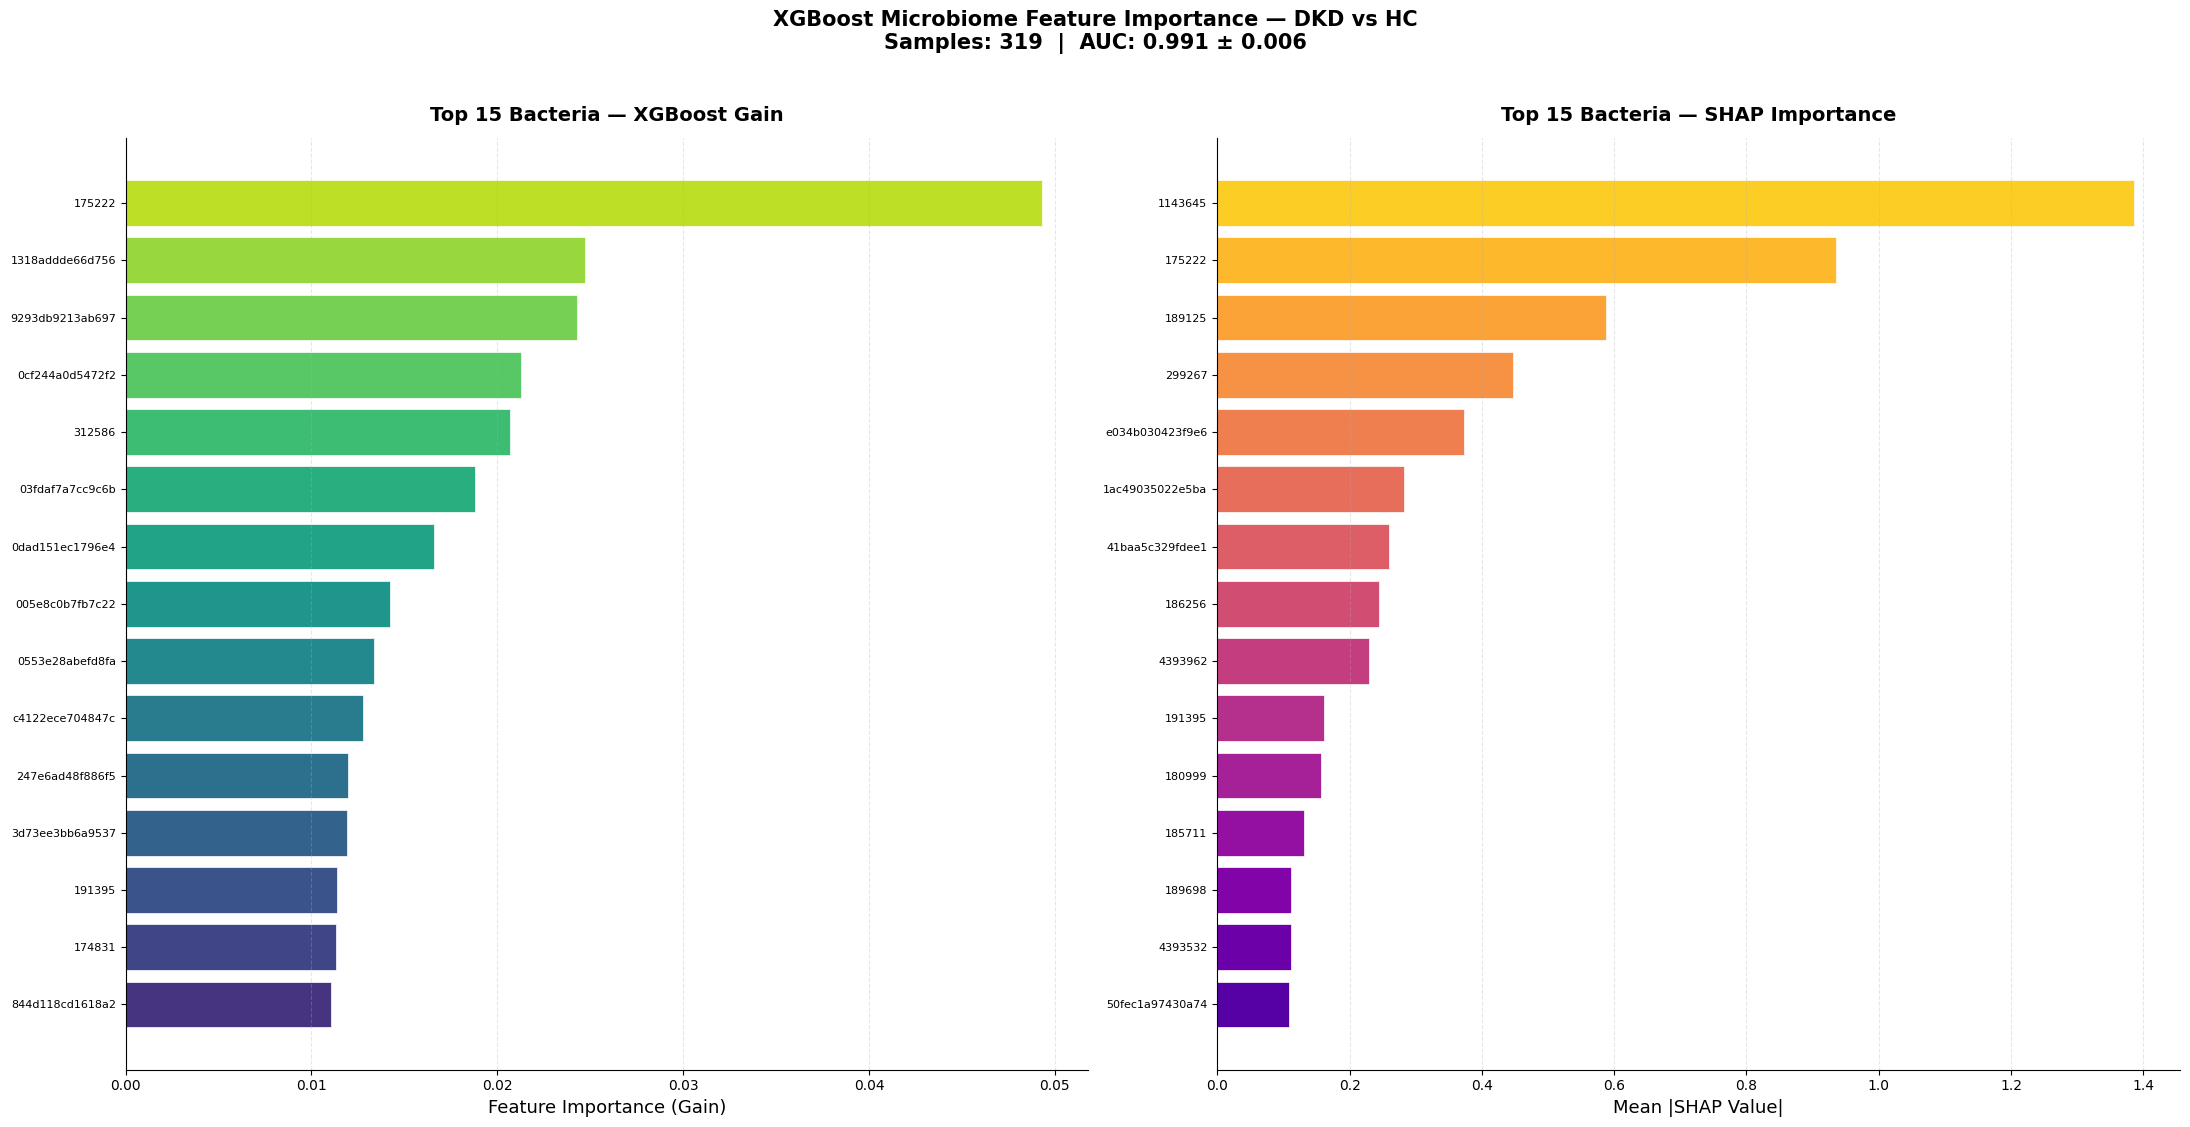

✅ Saved: importance_plots.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

# ── Left: XGBoost gain ─────────────────────────────────────────────
top_imp = importance_df.head(TOP_N).sort_values("Importance")
cmap_a  = plt.cm.viridis(np.linspace(0.15, 0.9, len(top_imp)))
bars_a  = axes[0].barh(top_imp["Label"], top_imp["Importance"], color=cmap_a, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Feature Importance (Gain)", fontsize=13)
axes[0].set_title(f"Top {TOP_N} Bacteria — XGBoost Gain", fontsize=14, fontweight="bold", pad=12)
axes[0].tick_params(axis="y", labelsize=8)
axes[0].grid(axis="x", alpha=0.3, linestyle="--")
axes[0].spines[["top","right"]].set_visible(False)

# ── Right: SHAP ────────────────────────────────────────────────────
top_shap = shap_df.head(TOP_N).sort_values("Mean_SHAP")
cmap_b   = plt.cm.plasma(np.linspace(0.15, 0.9, len(top_shap)))
bars_b   = axes[1].barh(top_shap["Label"], top_shap["Mean_SHAP"], color=cmap_b, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Mean |SHAP Value|", fontsize=13)
axes[1].set_title(f"Top {TOP_N} Bacteria — SHAP Importance", fontsize=14, fontweight="bold", pad=12)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].grid(axis="x", alpha=0.3, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(
    f"XGBoost Microbiome Feature Importance — DKD vs HC\n"
    f"Samples: {len(X)}  |  AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("importance_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: importance_plots.png")


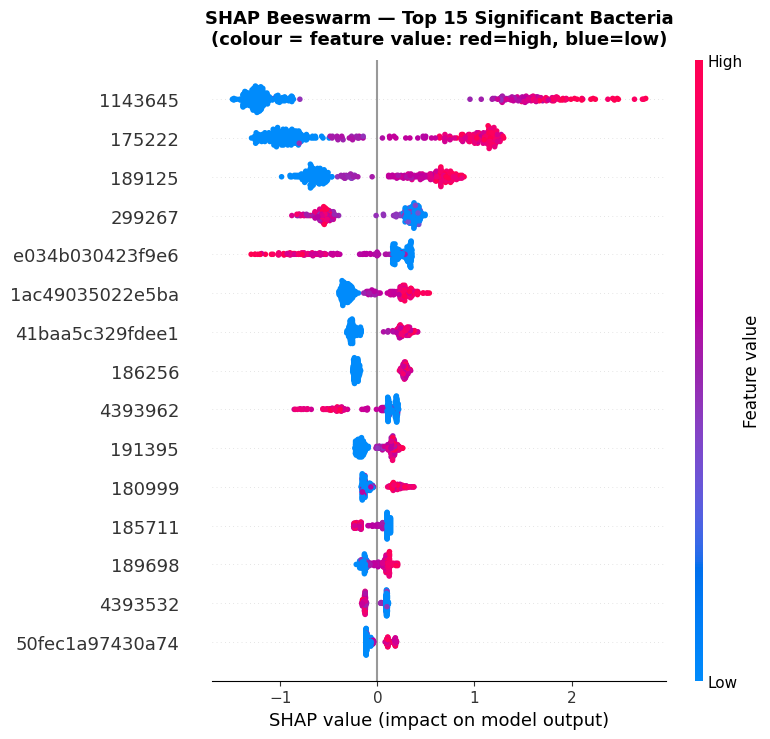

✅ Saved: shap_beeswarm.png


In [24]:
top_fids   = shap_df.head(TOP_N)["Feature_ID"].tolist()
top_idx    = [feature_names.index(f) for f in top_fids if f in feature_names]
top_labels = [shap_df.loc[shap_df["Feature_ID"] == feature_names[i], "Label"].values[0]
               for i in top_idx]

shap_vals_plot = shap_values[0] if isinstance(shap_values, list) else shap_values
base_val       = (explainer.expected_value[0]
                  if isinstance(explainer.expected_value, (list, np.ndarray))
                  else explainer.expected_value)

explanation = shap.Explanation(
    values      = shap_vals_plot[:, top_idx],
    base_values = base_val,
    data        = X[:, top_idx],
    feature_names = top_labels
)

plt.figure(figsize=(12, 11))
shap.plots.beeswarm(explanation, show=False, max_display=TOP_N)
plt.title(f"SHAP Beeswarm — Top {TOP_N} Significant Bacteria\n"
          f"(colour = feature value: red=high, blue=low)",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm.png")


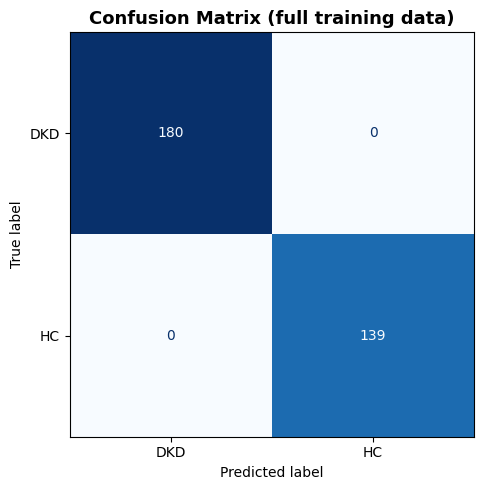


Classification Report:
              precision    recall  f1-score   support

         DKD       1.00      1.00      1.00       180
          HC       1.00      1.00      1.00       139

    accuracy                           1.00       319
   macro avg       1.00      1.00      1.00       319
weighted avg       1.00      1.00      1.00       319

✅ Saved: confusion_matrix.png


In [25]:
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(max(6, n_classes * 2), max(5, n_classes * 1.8)))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels = classes,
    cmap           = "Blues",
    ax             = ax,
    colorbar       = False
)
ax.set_title("Confusion Matrix (full training data)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=classes))
print("✅ Saved: confusion_matrix.png")

In [26]:
if has_taxonomy and "Phylum" in shap_df.columns:
    phylum_imp = (
        shap_df.dropna(subset=["Phylum"])
        .groupby("Phylum")["Mean_SHAP"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    phylum_imp = phylum_imp[phylum_imp["Phylum"] != "Unknown"]

    palette = sns.color_palette("tab20", len(phylum_imp))
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(phylum_imp["Phylum"], phylum_imp["Mean_SHAP"],
                  color=palette, edgecolor="white", linewidth=0.7)
    ax.set_xlabel("Phylum", fontsize=12)
    ax.set_ylabel("Summed Mean |SHAP|", fontsize=12)
    ax.set_title("Cumulative SHAP Importance by Phylum", fontsize=14, fontweight="bold")
    ax.set_xticklabels(phylum_imp["Phylum"], rotation=40, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("phylum_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: phylum_importance.png")
else:
    print("⚠️  Phylum plot skipped — taxonomy not mapped.")

⚠️  Phylum plot skipped — taxonomy not mapped.


In [27]:
from google.colab import files as colab_files

# Save CSVs
importance_df.to_csv("xgboost_feature_importance.csv", index=False)
shap_df.to_csv("xgboost_shap_importance.csv", index=False)
print("✅ CSVs saved")

# Summary
print("\n" + "═" * 55)
print("  ANALYSIS COMPLETE — SUMMARY")
print("═" * 55)
print(f"  Samples analysed  : {len(X)}")
print(f"  Features used     : {len(feature_names)}")
print(f"  Target variable   : {TARGET_COLUMN}")
print(f"  Classes           : {list(classes)}")
print(f"  CV AUC            : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\n  Top 10 Significant Bacteria (SHAP ranking):")
print("  " + "─"*45)
disp_cols = ["Label","Mean_SHAP","Genus","Phylum"] if has_taxonomy else ["Label","Mean_SHAP"]
print(shap_df[disp_cols].head(10).to_string(index=False))
print("═" * 55)

# Download all result files
print("\n📥 Downloading result files...")
for fname in [
    "xgboost_feature_importance.csv",
    "xgboost_shap_importance.csv",
    "importance_plots.png",
    "shap_beeswarm.png",
    "confusion_matrix.png",
    "phylum_importance.png",
]:
    try:
        colab_files.download(fname)
        print(f"   ✅ {fname}")
    except Exception as e:
        print(f"   ⚠️  {fname} — {e}")


✅ CSVs saved

═══════════════════════════════════════════════════════
  ANALYSIS COMPLETE — SUMMARY
═══════════════════════════════════════════════════════
  Samples analysed  : 319
  Features used     : 28378
  Target variable   : Groups
  Classes           : ['DKD', 'HC']
  CV AUC            : 0.9908 ± 0.0064

  Top 10 Significant Bacteria (SHAP ranking):
  ─────────────────────────────────────────────
          Label  Mean_SHAP
        1143645   1.386246
         175222   0.935426
         189125   0.588416
         299267   0.446630
e034b030423f9e6   0.373737
1ac49035022e5ba   0.281870
41baa5c329fdee1   0.259028
         186256   0.244506
        4393962   0.229318
         191395   0.161936
═══════════════════════════════════════════════════════

📥 Downloading result files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ xgboost_feature_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ shap_beeswarm.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ confusion_matrix.png
   ⚠️  phylum_importance.png — Cannot find file: phylum_importance.png
